In [2]:
import numpy as np
from sympy import *

In [3]:
# lets we have multiple tower whose coordinate are
tx = [2,4,6,8,9]
ty = [3,6,8,2,5]


# lets define cost function c(m,b) for these points
m,b = symbols('m b')

cost = 0

for i in range(len(tx)):
    cost += (m*tx[i] + b - ty[i])**2

print(cost)

(b + 2*m - 3)**2 + (b + 4*m - 6)**2 + (b + 6*m - 8)**2 + (b + 8*m - 2)**2 + (b + 9*m - 5)**2


In [4]:
#calculate the gradient
from sympy.utilities.lambdify import lambdify

dcdm_exp = diff(cost,m)
dcdb_exp = diff(cost,b)

dcdm = lambdify((m,b),dcdm_exp,'numpy')
dcdb = lambdify((m,b),dcdb_exp,'numpy')

In [5]:
# now let define the gradient descent

def gradient_descent(dcdm,dcdb,a,c,alpha=0.1,iteration=100):
    history = []
    cost_data = []
    for i in range(iteration):
        a , c = a - alpha*dcdm(a,c) , c - alpha*dcdb(a,c)
        cos = cost.evalf(subs={m:a,b:c})

        history.append((a,c))
        cost_data.append(cos)
        print("m:",a,"b:",c,"cost:",cos)

    return a,c,history,cost_data

In [6]:
#test the gradient descent for (m,b) = (4,8)

a,c,history,cost_data = gradient_descent(dcdm,dcdb,4,8,0.0001,10000)
# gradient_descent(dcdm,dcdb,10,15,0.001,5000)
# gradient_descent(dcdm,dcdb,0,0,0.001,10000)
# gradient_descent(dcdm,dcdb,4,8,0.001,2000)

m: 3.8205999999999998 b: 7.9736 cost: 3711.93403844000
m: 3.6485649999999996 b: 7.94826692 cost: 3415.76076411030
m: 3.4835927388639996 b: 7.92395697608 cost: 3143.39850808796
m: 3.325393360300403 b: 7.900628181218509 cost: 2892.93295934358
m: 3.1736889037652594 b: 7.878240271547548 cost: 2662.60370983298
m: 3.0282128162589204 b: 7.856754635634162 cost: 2450.79188130997
m: 2.8887094841586336 b: 7.836134246664225 cost: 2256.00874689401
m: 2.754933784264804 b: 7.816343597409441 cost: 2076.88526741861
m: 2.6266506532723843 b: 7.797348637863296 cost: 1912.16246901566
m: 2.5036346749112273 b: 7.7791167154364524 cost: 1760.68259430363
m: 2.3856696840302645 b: 7.761616517606531 cost: 1621.38096498500
m: 2.27254838693013 b: 7.744818016921549 cost: 1493.27849865854
m: 2.164071997277394 b: 7.728692418260433 cost: 1375.47482724999
m: 2.060049886960932 b: 7.713212108257964 cost: 1267.14196869359
m: 1.9602992512772064 b: 7.698350606805333 cost: 1167.51850738515
m: 1.8646447878563917 b: 7.6840825205

# lets make a visualizer how line intially and than shift by rauurin grad descent

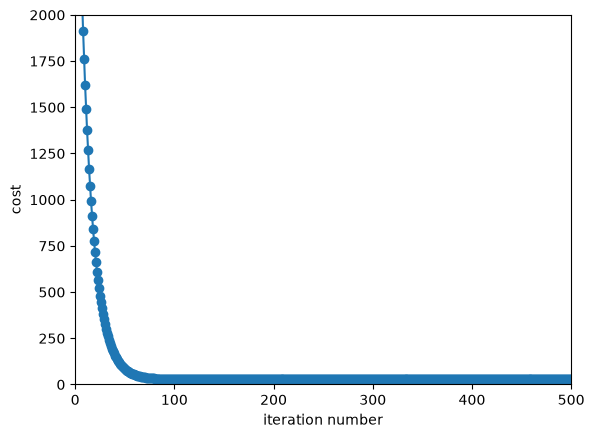

In [7]:
import matplotlib.pyplot as plt 

iteration = [i for i in range(10000)]

plt.xlim(0,500)
plt.ylim(0,2000)
plt.xlabel('iteration number')
plt.ylabel('cost')
plt.plot(iteration,cost_data)
plt.scatter(iteration,cost_data)
plt.show()

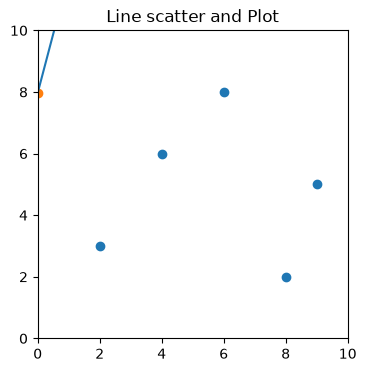

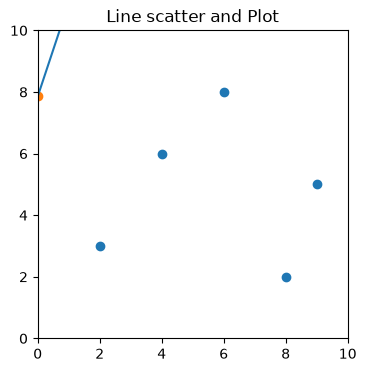

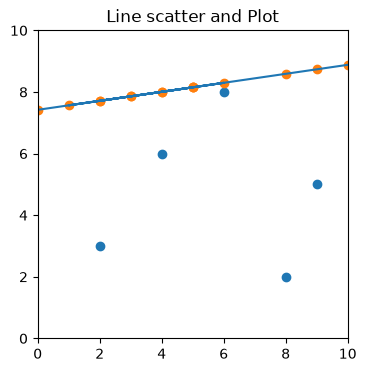

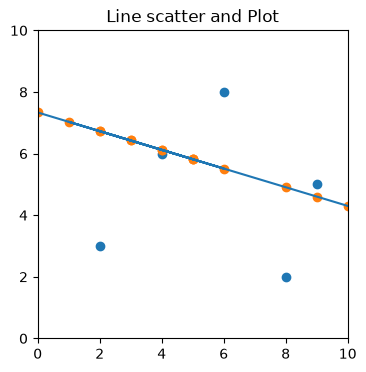

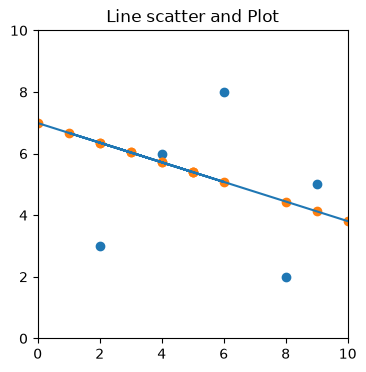

In [ ]:
# some basic of matplotlib animation 


x = [0,3,4,5,2,5,6,1,2,3,4,5,8,9,10,12,14]
for j in range(len(history)):
    if j in [0,5,50,100,1000,99999]:
        y = [i*history[j][0] + history[j][1] for i in x]
        plt.figure(figsize=(4,4))
        plt.title('Line scatter and Plot')
        plt.xlim(0,10)
        plt.ylim(0,10)
        plt.scatter(tx,ty)
        plt.scatter(x,y)
        plt.plot(x,y)
        plt.show()






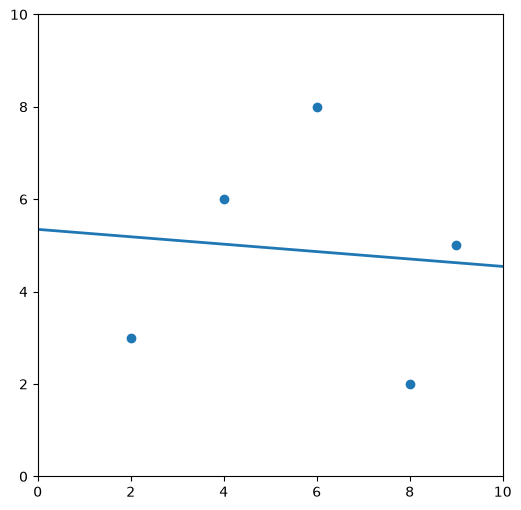

In [120]:
from matplotlib.animation import FuncAnimation
 
fig, ax = plt.subplots(figsize=(6, 6))

ax.set_xlim(0, 10)
ax.set_ylim(0, 10)

ax.scatter(tx, ty)

line, = ax.plot([], [], lw=2)
x = [0, 10]

def init():
    line.set_data([], [])
    return line,

def animate(frame):

    m = history[frame][0]
    b = history[frame][1]

    y = [m * i + b for i in x]

    line.set_data(x, y)

    return line,


anim = FuncAnimation(
    fig,
    animate,
    init_func=init,
    frames=len(history),
    interval=50,
    blit=True
)

anim.save(
    "gradientdescentline.mp4",
    writer="ffmpeg",
    fps=30
)

In [ ]:
# curve visulaize
# print(cost)

# def cost_eval(i,j):
#     return cost.evalf(subs={m:i,b:j})

# z = np.linspace(0, 1, 100)
# mx = [2,67,10]
# by = [5,48,40]
# z = [cost_eval(mx[i],by[i]) for i in range(len(mx))]



(b + 2*m - 3)**2 + (b + 4*m - 6)**2 + (b + 6*m - 8)**2 + (b + 8*m - 2)**2 + (b + 9*m - 5)**2


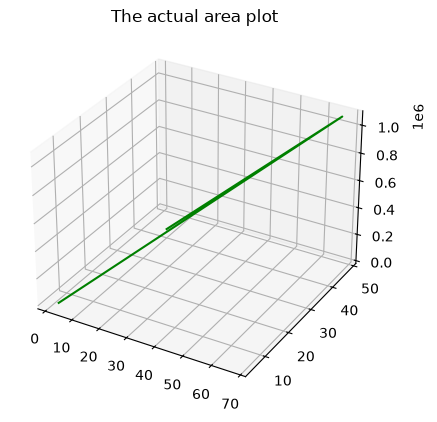

In [ ]:
# fig = plt.figure()
# ax = plt.axes(projection='3d')
# ax.set_title('The actual area plot')

# ax.plot(mx,by,z,'green')
# plt.show()